In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Styling ---
sns.set_theme(style='whitegrid')
plt.rcParams["font.sans-serif"] = "Arial"

# --- Path Configuration ---
PROJ_ROOT   = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CSV_PATH    = PROJ_ROOT / "data" / "processed" / "final_bearing_features_processing.csv"
RAW_DATA_DIR = PROJ_ROOT / "data" / "raw" / "2nd_test" / "2nd_test"
PLOTS_DIR   = PROJ_ROOT / "docs"

# --- Data Loading ---
df = pd.read_csv(CSV_PATH)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()


Dataset loaded: 980 rows, 19 columns.


,file_id,filename,b1_rms,b1_kurtosis,b1_skewness,label,peak_freq_hz,spectral_centroid,spectral_energy,top_freq_1_hz,top_amp_1,top_freq_2_hz,top_amp_2,top_freq_3_hz,top_amp_3,top_freq_4_hz,top_amp_4,top_freq_5_hz,top_amp_5
0,0,2004.02.12.10.32.39,0.074179,0.628763,0.083993,Normal,1009.0,4173.309307,0.010795,1009.0,0.042302,51.0,0.011834,237.0,0.005546,4372.0,0.004718,4640.0,0.004434
1,1,2004.02.12.10.42.39,0.075382,0.648291,0.052142,Normal,1009.0,4197.722211,0.011350,1009.0,0.035461,51.0,0.012307,237.0,0.007209,4433.0,0.005447,4675.0,0.004663
2,2,2004.02.12.10.52.39,0.076230,0.513475,0.032808,Normal,1009.0,4149.606739,0.011609,1009.0,0.033781,51.0,0.011630,4479.0,0.006478,474.0,0.006135,4723.0,0.004400
3,3,2004.02.12.11.02.39,0.078724,1.157953,0.041486,Normal,1009.0,4125.136873,0.012383,1009.0,0.034970,51.0,0.011518,4695.0,0.006032,4393.0,0.005510,4264.0,0.004083
4,4,2004.02.12.11.12.39,0.078474,0.603177,0.028224,Normal,1009.0,4141.750190,0.012304,1009.0,0.031891,51.0,0.010675,474.0,0.006390,4479.0,0.006086,3555.0,0.004712


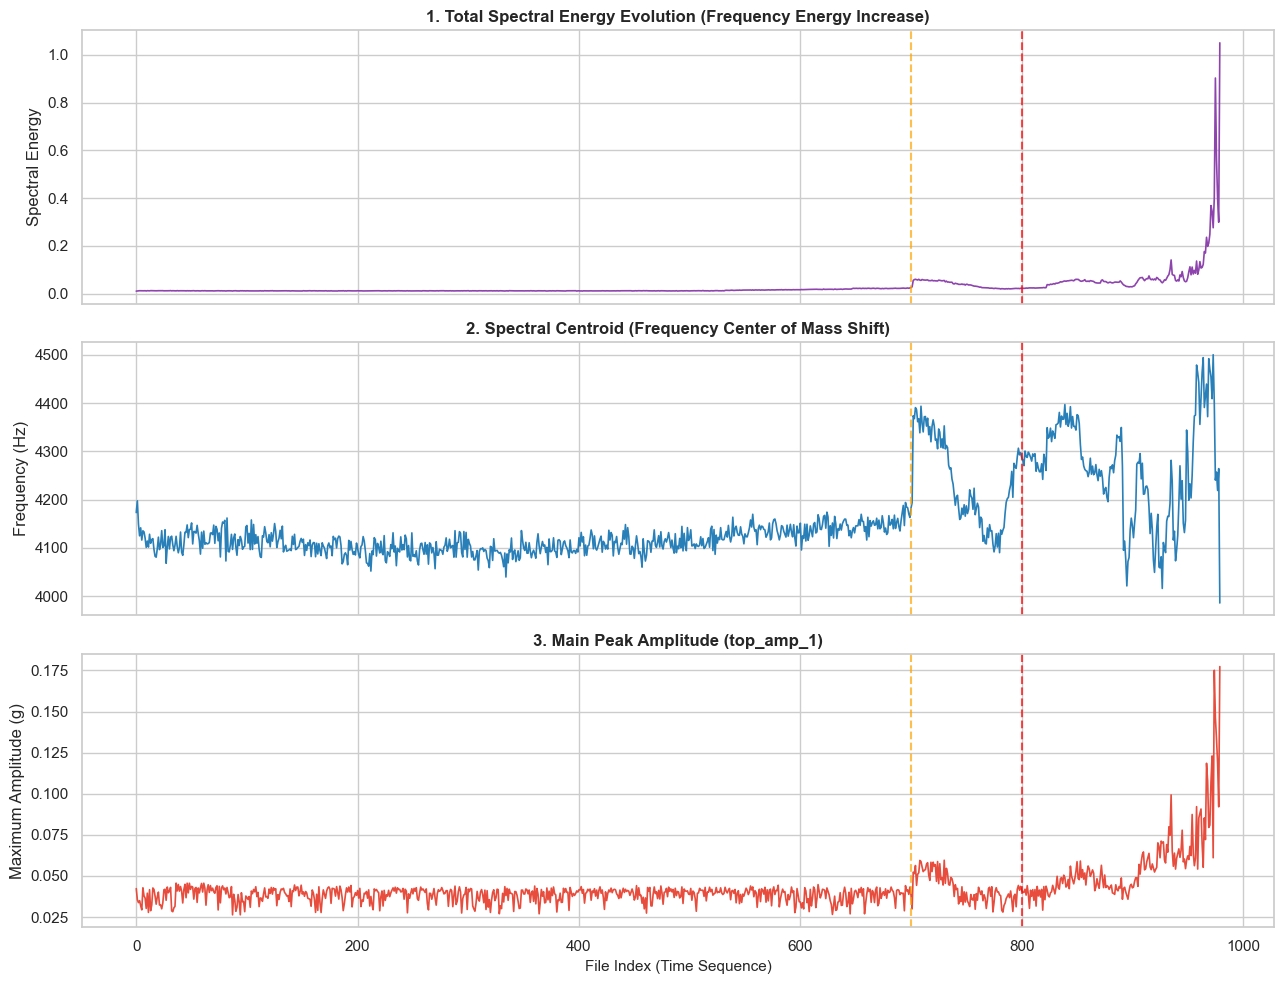

In [7]:
# --- 3-Panel Frequency Feature Time-Series Plot ---

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
ax1, ax2, ax3 = axes[0], axes[1], axes[2]

# --- Plot 1: Total Spectral Energy ---
sns.lineplot(x=df.index, y="spectral_energy", data=df,
             color="#8e44ad", linewidth=1.2, ax=ax1)
ax1.set_title("1. Total Spectral Energy Evolution (Frequency Energy Increase)",
              fontsize=12, fontweight="bold")
ax1.set_ylabel("Spectral Energy")
ax1.axvline(x=700, color="orange", linestyle="--", alpha=0.7)
ax1.axvline(x=800, color="red",    linestyle="--", alpha=0.7)

# --- Plot 2: Spectral Centroid ---
sns.lineplot(x=df.index, y="spectral_centroid", data=df,
             color="#2980b9", linewidth=1.2, ax=ax2)
ax2.set_title("2. Spectral Centroid (Frequency Center of Mass Shift)",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Frequency (Hz)")
ax2.axvline(x=700, color="orange", linestyle="--", alpha=0.7)
ax2.axvline(x=800, color="red",    linestyle="--", alpha=0.7)

# --- Plot 3: Main Peak Amplitude ---
sns.lineplot(x=df.index, y="top_amp_1", data=df,
             color="#e74c3c", linewidth=1.2, ax=ax3)
ax3.set_title("3. Main Peak Amplitude (top_amp_1)",
              fontsize=12, fontweight="bold")
ax3.set_xlabel("File Index (Time Sequence)", fontsize=11)
ax3.set_ylabel("Maximum Amplitude (g)")
ax3.axvline(x=700, color="orange", linestyle="--", alpha=0.7)
ax3.axvline(x=800, color="red",    linestyle="--", alpha=0.7)

# Hide x-tick labels on upper subplots after all plots are drawn
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)

# --- Save and Display ---
plt.tight_layout()
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOTS_DIR / "frequency_features_trends.png", dpi=300, bbox_inches="tight")
plt.show()


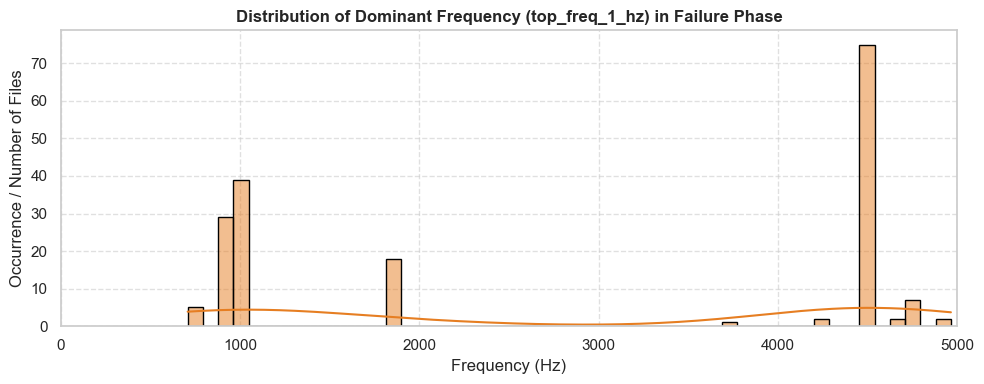

In [9]:
# --- Histogram: Distribution of Dominant Frequency in Failure Phase ---

# Filter records in the failure phase (index >= 800)
failure_df = df.iloc[800:] if len(df) >= 800 else df

plt.figure(figsize=(10, 4))

sns.histplot(
    failure_df["top_freq_1_hz"],
    bins=50,
    kde=True,
    color="#e67e22",
    edgecolor="black"
)

plt.title("Distribution of Dominant Frequency (top_freq_1_hz) in Failure Phase",
          fontsize=12, fontweight="bold")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Occurrence / Number of Files")

plt.xlim(0, 5000)  # Zoom to low/medium frequencies
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig(PLOTS_DIR / "Domain_frequency_trends.png", dpi=300)
plt.show()


🟢 Normal File: 2004.02.12.10.32.39
🔴 Max Fault File (-5): 2004.02.19.05.42.39


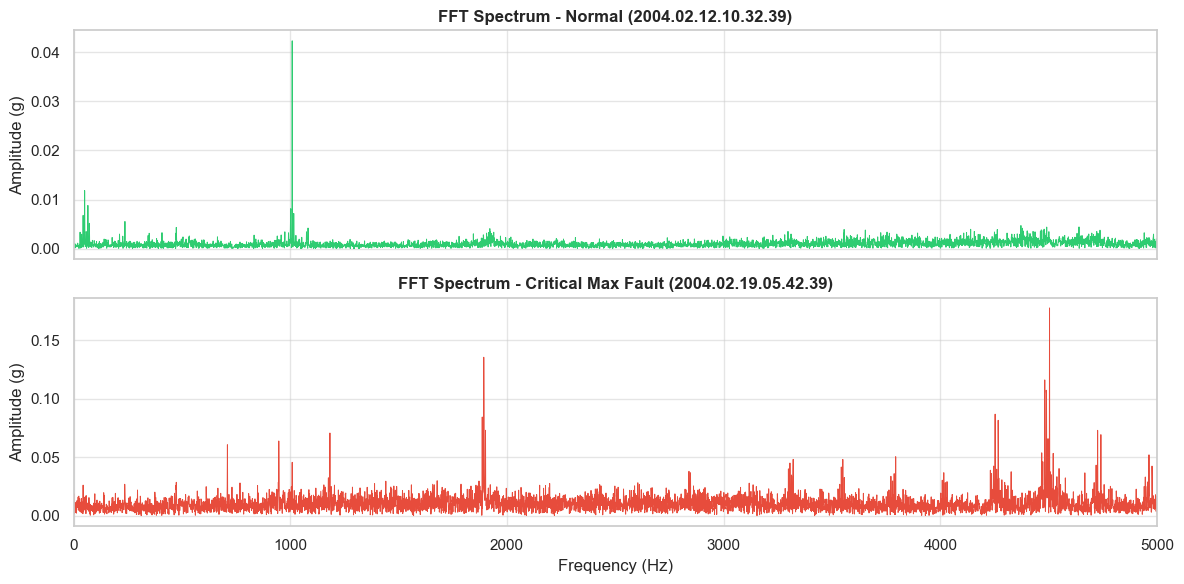

In [11]:
# --- FFT Analysis: Normal vs Critical Fault Signal ---

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import rfft, rfftfreq

# --- Configuration ---
PROJ_ROOT    = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJ_ROOT / "data" / "raw" / "2nd_test" / "2nd_test"
PLOTS_DIR    = PROJ_ROOT / "docs"
FS           = 20480  # Sampling frequency (Hz)


# --- FFT Function ---
def get_fft(signal, fs=FS):
    """Compute the single-sided FFT magnitude spectrum of a 1D signal."""
    signal_detrend = signal - np.mean(signal)
    fft_vals  = rfft(signal_detrend)
    freqs     = rfftfreq(len(signal), 1 / fs)
    magnitude = np.abs(fft_vals) * (2.0 / len(signal))
    return freqs, magnitude


# --- File Selection ---
files       = sorted(list(RAW_DATA_DIR.glob("*")))
file_normal = files[0]
file_fault  = files[-5]  # -5 skips the last 4 null/corrupted files

print(f"\U0001f7e2 Normal File: {file_normal.name}")
print(f"\U0001f534 Max Fault File (-5): {file_fault.name}")

# --- Load Bearing 1 Signal (column 0) ---
sig_normal = np.loadtxt(file_normal)[:, 0]
sig_fault  = np.loadtxt(file_fault)[:, 0]

# --- Compute FFT ---
freqs_n, mag_n = get_fft(sig_normal)
freqs_f, mag_f = get_fft(sig_fault)

# --- Visualization ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Subplot 0: Normal state
axes[0].plot(freqs_n, mag_n, color="#2ecc71", linewidth=0.7)
axes[0].set_title(f"FFT Spectrum - Normal ({file_normal.name})", fontweight="bold")
axes[0].set_ylabel("Amplitude (g)")
axes[0].set_xlim(0, 5000)
axes[0].grid(alpha=0.5)

# Subplot 1: Critical fault state
axes[1].plot(freqs_f, mag_f, color="#e74c3c", linewidth=0.7)
axes[1].set_title(f"FFT Spectrum - Critical Max Fault ({file_fault.name})", fontweight="bold")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude (g)")
axes[1].set_xlim(0, 5000)
axes[1].grid(alpha=0.5)

# --- Save and Display ---
plt.tight_layout()
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOTS_DIR / "frequency_spectrum.png", dpi=300)
plt.show()
